In [12]:
import xarray as xr
import numpy as np
import cftime
import cmocean as cm
import matplotlib.pyplot as plt
import regionmask
from xmip.regionmask import merged_mask
import cartopy.crs as ccrs
import os
import pandas as pd
from pandas import Timestamp
from xarrayutils.plotting import linear_piecewise_scale
import matplotlib
from matplotlib.ticker import MaxNLocator

In [4]:
Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr' #all vars 
Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975TempOnlyEpochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr'

In [5]:
def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})


    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})

    return ds_out

levels = 19
emulation_stability=False
smooth = False

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data/", "OM4_5daily_v0.2.1.zarr")
)

# Smooth the data 
if smooth:
    window = 10
    with ProgressBar():
        ds_input['uo'] = ds_input.uo.rolling(time=window, min_periods=1, center=False).mean().compute()
        ds_input['vo'] = ds_input.vo.rolling(time=window, min_periods=1, center=False).mean().compute()


# our groundtruth is always just a time slice of the training (training is a bad name

if emulation_stability:
    repeats = 100
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 7003))
else:
    ds_input = ds_input.sel(time=slice("1975-01-01", None))
    ds_groundtruth = ds_input.isel(time=slice(2903, 3503)).isel(lev=slice(None, levels))

ls_all = ['uo', 'vo', 'thetao', 'so', 'zos'] #['uo', 'vo', 'thetao', 'so', 'zos'], ['thetao', 'so', 'zos']
ls_temp = ['thetao', 'so', 'zos']
output_folder_all = Pred_path_all.split("/")[-2].split("_Train")[0]
output_path_all = os.path.join("./temp", output_folder_all)
output_folder_temp = Pred_path_all.split("/")[-2].split("_Train")[0]
output_path_temp = os.path.join("./temp", output_folder_temp)

if os.path.isdir(output_path_all):
    print("Using Output Folder : ", output_path_all)
else:
    print("Using Output Folder : ../outputs")
    output_path_all = "../outputs"

if os.path.isdir(output_path_temp):
    print("Using Output Folder : ", output_path_temp)
else:
    print("Using Output Folder : ../outputs")
    output_path_temp = "../outputs"

ds_prediction_raw_all = xr.open_zarr(Pred_path_all)
ds_prediction_raw_all = ds_prediction_raw_all.isel(time = slice(0,600))

ds_prediction_raw_temp = xr.open_zarr(Pred_path_temp)
ds_prediction_raw_temp = ds_prediction_raw_temp.isel(time = slice(0,600))
# if emulation_stability:
#     ds_groundtruth = ds_groundtruth.isel(time=slice(0, ds_prediction_raw.time.size))

ds_prediction_all = post_processor(
    ds_prediction_raw_all, ds_groundtruth, ls_all
)
ds_prediction_temp = post_processor(
    ds_prediction_raw_temp, ds_groundtruth, ls_temp
)


# Run the test to make sure the output is formatted correctly
ds_prediction_all = ds_prediction_all.transpose('time','lev',...)
ds_prediction_temp = ds_prediction_temp.transpose('time','lev',...)

Using Output Folder : ../outputs
Using Output Folder : ../outputs


In [6]:
data = xr.open_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr").drop_vars(['lon','lat'])
time_slice = slice(ds_prediction_all['time'][0],ds_prediction_all['time'][-1])
data = data.sel(time = time_slice)
data = data.transpose('time','lev',...)

In [7]:
ds_prediction_all['y']  = ds_prediction_all.y.assign_attrs(long_name='latitude', units = r"${^o}$")
ds_prediction_all['x']  = ds_prediction_all.x.assign_attrs(long_name='longitude', units = r"${^o}$")
ds_prediction_all['thetao'] = ds_prediction_all['thetao'].assign_attrs(long_name = r"${\theta_O}$", units = r"$^oC$")
ds_prediction_all['lev'] = ds_prediction_all['lev'].assign_attrs(long_name = 'depth', units = 'm')

ds_prediction_temp['y']  = ds_prediction_temp.y.assign_attrs(long_name='latitude', units = r"${^o}$")
ds_prediction_temp['x']  = ds_prediction_temp.x.assign_attrs(long_name='longitude', units = r"${^o}$")
ds_prediction_temp['thetao'] = ds_prediction_temp['thetao'].assign_attrs(long_name = r"${\theta_O}$", units = r"$^oC$")
ds_prediction_temp['lev'] = ds_prediction_temp['lev'].assign_attrs(long_name = 'depth', units = 'm')

data['y']  = data.y.assign_attrs(long_name='latitude', units = r"${^o}$")
data['x']  = data.x.assign_attrs(long_name='longitude', units = r"${^o}$")
data['thetao'] = data['thetao'].assign_attrs(long_name = r"${\theta_O}$", units = r"$^oC$")
data['lev'] = data['lev'].assign_attrs(long_name = 'depth', units = 'm')

ds_prediction_temp['so'] = ds_prediction_temp['so'].assign_attrs(long_name = r"${s}$", units = r"psu")
ds_prediction_all['so'] = ds_prediction_all['so'].assign_attrs(long_name = r"${s}$", units = r"psu")
data['so'] = data['so'].assign_attrs(long_name = r"${s}$", units = r"psu")

ds_prediction_temp['zos'] = ds_prediction_temp['zos'].assign_attrs(long_name = r"SSH", units = r"m")
ds_prediction_all['zos'] = ds_prediction_all['zos'].assign_attrs(long_name = r"SSH", units = r"m")
data['zos'] = data['zos'].assign_attrs(long_name = r"SSH", units = r"m")    

ds_prediction_all['uo'] = ds_prediction_all['uo'].assign_attrs(long_name = r"${u}$", units = r"m/s")
data['uo'] = data['uo'].assign_attrs(long_name = r"${u}$", units = r"m/s")
ds_prediction_all['vo'] = ds_prediction_all['vo'].assign_attrs(long_name = r"${v}$", units = r"m/s")
data['vo'] = data['vo'].assign_attrs(long_name = r"${v}$", units = r"m/s")



/state/partition1/job-50878230/ipykernel_2766438/2953378196.py:3: UserWarning: `natural_earth_v4_1_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` instead. See https://github.com/regionmask/regionmask/issues/410.
  basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50
/ext3/miniconda3/lib/python3.10/site-packages/regionmask/core/mask.py:179: FutureWarning: Passing 'lon_name' and 'lat_name' was deprecated in v0.10.0. Please pass the coordinates directly, e.g., `mask*(ds[lon_name], ds[lat_name])`.
  warnings.warn(


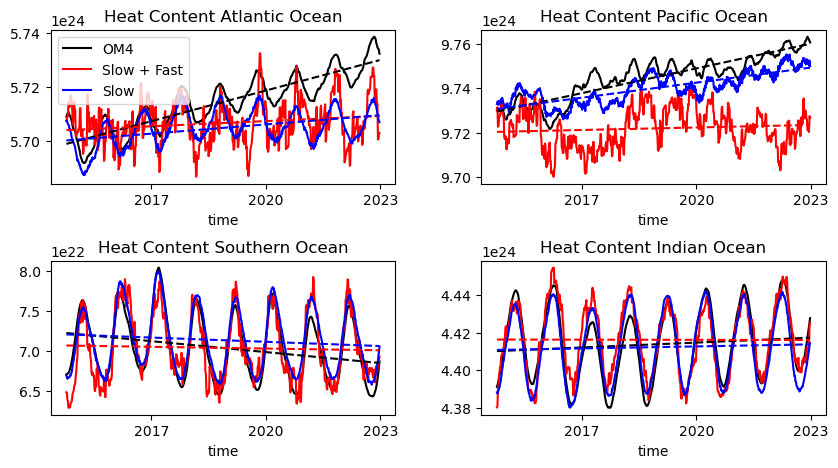

In [8]:
# Compute Basin Heat Content Time Series

basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50

mask = merged_mask(basins,data)

atlantic_mask = xr.where(np.logical_or(mask == 0,mask == 1),1.0,np.nan)
pacific_mask = xr.where(np.logical_or(mask == 2,mask == 3),1.0,np.nan)
southern_ocean_mask = xr.where(mask == 7,1.0,np.nan)
indian_ocean_mask = xr.where(mask == 5,1.0,np.nan)

masks = atlantic_mask.to_dataset(name='Atlantic')
masks['Pacific']  = pacific_mask
masks['Southern'] = southern_ocean_mask
masks['Indian'] = indian_ocean_mask

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
ax_flat = ax.flatten()

for i, var in enumerate(list(masks.keys())):
    OHC_pred_all = ((ds_prediction_all['thetao']*c_p*rho_0*masks[var])*data['areacello']*data['dz']).sum(['x','y','lev'])    
    OHC_pred_temp = ((ds_prediction_temp['thetao']*c_p*rho_0*masks[var])*data['areacello']*data['dz']).sum(['x','y','lev'])    
    OHC = ((data['thetao']*c_p*rho_0*masks[var])*data['areacello']*data['dz']).sum(['x','y','lev'])
    OHC = OHC.rename('Ocean Heat Content')
    OHC = OHC.assign_attrs(units = 'J')
    OHC.plot(ax = ax_flat[i], label = 'OM4',c = 'k')

    OHC_pred_all.plot(ax = ax_flat[i], label = r"Slow + Fast", c = 'r')
    OHC_pred_all = OHC_pred_all.rename('Ocean Heat Content')
    OHC_pred_all = OHC_pred_all.assign_attrs(units = 'J')    

    OHC_pred_temp.plot(ax = ax_flat[i], label = 'Slow', c = 'b')
    OHC_pred_temp = OHC_pred_temp.rename('Ocean Heat Content')
    OHC_pred_temp = OHC_pred_temp.assign_attrs(units = 'J') 
    if i == 0:
        ax_flat[i].legend()
    ax_flat[i].set_title("Heat Content " + var + " Ocean")
    coeffs_OHC_trend = np.polyfit(np.arange(OHC.size), OHC, 1)
    coeffs_OHC_pred_trend_all= np.polyfit(np.arange(OHC_pred_all.size), OHC_pred_all, 1)
    coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_temp.size), OHC_pred_temp, 1)

    ax_flat[i].plot(OHC.time.data, np.arange(OHC.size)*coeffs_OHC_trend[0] + coeffs_OHC_trend[1],c = 'k', ls = '--')
    ax_flat[i].plot(OHC_pred_all.time.data, np.arange(OHC_pred_all.size)*coeffs_OHC_pred_trend_all[0] + coeffs_OHC_pred_trend_all[1],c = 'r', ls = '--')
    ax_flat[i].plot(OHC_pred_temp.time.data, np.arange(OHC_pred_temp.size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = 'b', ls = '--')

plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Basin_OHC_Short.png", bbox_inches='tight')


4.299602550757828
1.8682135993844826
9.875848010407076
0.6157440713900721
-48.85221803332941
-10.59522491842728


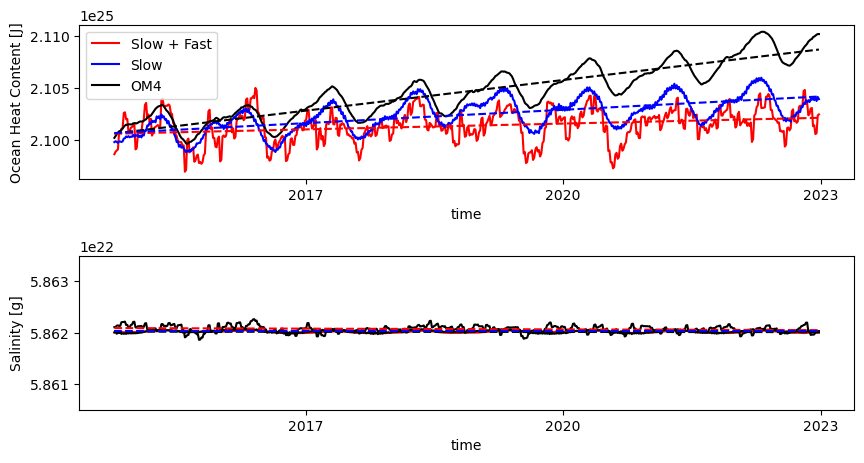

In [9]:
# Compute Basin Heat Content Time Series

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,1,figsize=(10,5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC = ((data['thetao']*c_p*rho_0)*data['areacello']*data['dz']).sum(['x','y','lev'])    
OHC = OHC.rename('Ocean Heat Content')
OHC = OHC.assign_attrs(units = 'J')

OHC_pred_all = ((ds_prediction_all['thetao']*c_p*rho_0)*data['areacello']*data['dz']).sum(['x','y','lev'])    
OHC_pred_all = OHC_pred_all.rename('Ocean Heat Content')
OHC_pred_all = OHC_pred_all.assign_attrs(units = 'J')

OHC_pred_temp = ((ds_prediction_temp['thetao']*c_p*rho_0)*data['areacello']*data['dz']).sum(['x','y','lev'])    
OHC_pred_temp = OHC_pred_temp.rename('Ocean Heat Content')
OHC_pred_temp = OHC_pred_temp.assign_attrs(units = 'J')

OHC_pred_all.plot(ax = ax[0], label = 'Slow + Fast', c = 'r')
OHC_pred_temp.plot(ax = ax[0], label = 'Slow', c = 'b')
OHC.plot(ax = ax[0], label = 'OM4', c = 'k')

# ax[0].legend()
# ax[0].set_title("Ocean Heat Content")
coeffs_OHC_trend= np.polyfit(np.arange(OHC.size), OHC, 1)
ax[0].plot(OHC.time.data, np.arange(OHC.size)*coeffs_OHC_trend[0] + coeffs_OHC_trend[1],c = 'k', ls = '--')

coeffs_OHC_pred_all_trend= np.polyfit(np.arange(OHC_pred_all.size), OHC_pred_all, 1)
ax[0].plot(OHC_pred_all.time.data, np.arange(OHC_pred_all.size)*coeffs_OHC_pred_all_trend[0] + coeffs_OHC_pred_all_trend[1],c = 'r', ls = '--')

coeffs_OHC_pred_temp_trend= np.polyfit(np.arange(OHC_pred_temp.size), OHC_pred_temp, 1)
ax[0].plot(OHC_pred_temp.time.data, np.arange(OHC_pred_temp.size)*coeffs_OHC_pred_temp_trend[0] + coeffs_OHC_pred_temp_trend[1],c = 'b', ls = '--')

ax[0].legend()

salinity = ((data['so']*rho_0)*data['areacello']*data['dz']).sum(['x','y','lev'])    
salinity = salinity.rename('Salinity')
salinity = salinity.assign_attrs(units = 'g')

salinity_pred_all = ((ds_prediction_all['so']*rho_0)*data['areacello']*data['dz']).sum(['x','y','lev'])    
salinity_pred_all = salinity_pred_all.rename('Salinity')
salinity_pred_all = salinity_pred_all.assign_attrs(units = 'g')

salinity_pred_temp = ((ds_prediction_temp['so']*rho_0)*data['areacello']*data['dz']).sum(['x','y','lev'])    
salinity_pred_temp = salinity_pred_temp.rename('Salinity')
salinity_pred_temp = salinity_pred_temp.assign_attrs(units = 'g')


salinity.plot(ax = ax[1], label = 'pred', c = 'r')
salinity_pred_all.plot(ax = ax[1], label = 'Slow + Fast', c = 'k')
salinity_pred_temp.plot(ax = ax[1], label = 'Slow', c = 'k')

ax[1].set_ylim([5.8605e+22, 5.8635e+22])

coeffs_salinity_trend= np.polyfit(np.arange(salinity.size), salinity, 1)
ax[1].plot(salinity.time.data, np.arange(salinity.size)*coeffs_salinity_trend[0] + coeffs_salinity_trend[1],c = 'k', ls = '--')

coeffs_salinity_pred_all_trend= np.polyfit(np.arange(salinity_pred_all.size), salinity_pred_all, 1)
ax[1].plot(salinity_pred_all.time.data, np.arange(salinity_pred_all.size)*coeffs_salinity_pred_all_trend[0] + coeffs_salinity_pred_all_trend[1],c = 'r', ls = '--')

coeffs_salinity_pred_temp_trend= np.polyfit(np.arange(salinity_pred_temp.size), salinity_pred_temp, 1)
ax[1].plot(salinity_pred_temp.time.data, np.arange(salinity_pred_temp.size)*coeffs_salinity_pred_temp_trend[0] + coeffs_salinity_pred_temp_trend[1],c = 'b', ls = '--')

print(coeffs_OHC_pred_temp_trend[0]*73/1e21)
print(coeffs_OHC_pred_all_trend[0]*73/1e21)
print(coeffs_OHC_trend[0]*73/1e21)

print(coeffs_salinity_pred_temp_trend[0]*73/1e15)
print(coeffs_salinity_pred_all_trend[0]*73/1e15)
print(coeffs_salinity_trend[0]*73/1e15)

plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/OHC_and_Salinity_Short.png", bbox_inches='tight')


In [23]:
#Drake Passage Full Depth 
new_cmap = cm.cm.thermal 

new_cmap.set_bad('grey',.6)

day_start = 597
window = 3
regions = {'Drake Passage': {'lon': 290, 'lat_bnds':slice(-70,-55)},
           'Atlantic': {'lon': 330, 'lat_bnds':slice(-80,90)}}
surface = False
fig, ax = plt.subplots(2,3,figsize=(10,6),gridspec_kw={'width_ratios': [1,1,1], 'height_ratios': [.9,.9], 'wspace': 0.25,'hspace':.4})

for i, region in enumerate(['Drake Passage', 'Atlantic']):
    bounds = regions[region]
    var = 'thetao'
    if surface:
        level_slice = slice(0,1000)
    else:
        level_slice = slice(None)
    
    depth_slice = data[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
    depth_slice = depth_slice.assign_attrs(long_name = data[var].long_name, units = r"^oC")
    depth_slice['y']  = depth_slice.y.assign_attrs(long_name='latitude')

    max_val = np.ceil(depth_slice.max()).values
    
    depth_slice.plot(ax=ax[i,0],add_colorbar=False, cmap = new_cmap, vmin = -2.5,vmax = max_val)
    ax[i,0].invert_yaxis()
    ax[i,0].set_title('OM4')
    linear_piecewise_scale(1000,5,ax =ax[i,0])
    ax[i,0].axhline(1000, color='0.5', ls='--')
    ax[i,0].set_yticks([0, 250, 500, 750, 1000, 3000, 5000]);

    depth_slice_pred = ds_prediction_all[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
    depth_slice_pred = depth_slice_pred.assign_attrs(long_name = data[var].long_name, units = r"^oC")
    pred_plot = depth_slice_pred.plot(ax=ax[i,1],add_colorbar=False,cmap = new_cmap, vmin = -2.5,vmax = max_val)
    ax[i,1].invert_yaxis()
    ax[i,1].set_ylabel('')
    ax[i,1].set_title('Slow + Fast')
    linear_piecewise_scale(1000,5,ax =ax[i,1])
    ax[i,1].axhline(1000, color='0.5', ls='--')
    ax[i,1].set_yticks([0, 250, 500, 750, 1000, 3000, 5000]);

    depth_slice_pred = ds_prediction_temp[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
    depth_slice_pred = depth_slice_pred.assign_attrs(long_name = data[var].long_name, units = r"^oC")
    pred_plot = depth_slice_pred.plot(ax=ax[i,2],add_colorbar=False,cmap = new_cmap, vmin = -2.5,vmax = max_val)
    ax[i,2].invert_yaxis()
    ax[i,2].set_ylabel('')
    ax[i,2].set_title('Slow')
    linear_piecewise_scale(1000,5,ax =ax[i,2])
    ax[i,2].axhline(1000, color='0.5', ls='--')
    ax[i,2].set_yticks([0, 250, 500, 750, 1000, 3000, 5000]);

    fig.subplots_adjust(right=0.825)
    cbar_ax = fig.add_axes([0.85, 0.125+.45*i, 0.015, 0.29])
    cbar = fig.colorbar(pred_plot, cax=cbar_ax)
    cbar.set_label(ds_prediction_temp[var].long_name,rotation = 90)
    
fig.text(0.02, 0.5, "Drake Passage" + r" lon: 70${^o}W$" , ha='center', fontsize=14, rotation=90)
fig.text(0.02, 0.125, region + r" lon: 30${^o}W$", ha='center', fontsize=14, rotation=90)    


# if surface:
#     fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Upper Oceans.png')
# else:
#     fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Full Oceans Profile.png')
plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Depth_Profiles_Short.png", bbox_inches='tight')


In [14]:
#Drake Passage Full Depth 
day_start = -103
window = 3
regions = {'Drake Passage': {'lon': 290, 'lat_bnds':slice(-70,-55)},
           'Atlantic': {'lon': 330, 'lat_bnds':slice(-80,90)}}
surface = False

N_days = 100
for i, region in enumerate(['Drake Passage', 'Atlantic']):
    mae_mean_all = 0
    mae_mean_temp = 0

    for j in range(N_days):

        bounds = regions[region]
        var = 'thetao'
        if surface:
            level_slice = slice(0,1000)
        else:
            level_slice = slice(None)
        
        depth_slice = data[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
    
        depth_slice_pred_all = ds_prediction_all[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
        depth_slice_pred_temp = ds_prediction_temp[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    

        mae_all = np.abs(depth_slice_pred_all - depth_slice)
        mae_all =( mae_all*data['areacello'].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'])*data['dz']).sum(['y','lev'])/(data['areacello'].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'])*data['dz']).sum()
        mae_all = mae_all.assign_attrs(long_name = 'MAE', units = r"${^oC}$")
        mae_mean_all += 1/N_days*mae_all.values

        mae_temp = np.abs(depth_slice_pred_temp - depth_slice)
        mae_temp =( mae_temp*data['areacello'].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'])*data['dz']).sum(['y','lev'])/(data['areacello'].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'])*data['dz']).sum()
        mae_temp = mae_temp.assign_attrs(long_name = 'MAE', units = r"${^oC}$")
        mae_mean_temp += 1/N_days*mae_temp.values
    print(mae_mean_all,region)
    print(mae_mean_temp,region)

    

0.07939219361676197 Drake Passage
0.06104595004334298 Drake Passage
0.08382039807705109 Atlantic
0.07151851423276416 Atlantic


In [15]:
# Create a figure
fig = plt.figure(figsize=(24, 15))
plt.rc('axes', titlesize=30)     # fontsize of the axes title
plt.rc('axes', labelsize=30)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=30)    # fontsize of the tick labels
plt.rc('ytick', labelsize=30)    # fontsize of the tick labels
plt.rc('legend', fontsize=20)    # legend fontsize
plt.rc('figure', titlesize=30)
# Manual positioning using add_axes with uniform width and height
width = 0.22
height = 0.3

# Top row: 3 plots, evenly spaced horizontally
axs = [
    fig.add_axes([0.05, 0.55, width, height]),  # First plot in top row
    fig.add_axes([0.38, 0.55, width, height]),  # Second plot in top row
    fig.add_axes([0.71, 0.55, width, height])   # Third plot in top row
]

# Bottom row: 2 plots centered, manually positioned
axs += [
    fig.add_axes([0.22, 0.1, width, height]),  # First plot in bottom row
    fig.add_axes([0.54, 0.1, width, height])  # Second plot in bottom row
]

# Plot PDFs
for i, v in enumerate(['thetao', 'so', 'zos', 'uo', 'vo']):
    min_val, max_val = ds_groundtruth[v].min().values, ds_groundtruth[v].max().values
    true_pdf, bins_true = np.histogram(data[v], bins=150, density=True, range=(min_val, max_val))
    pdf_net, bins_net = np.histogram(ds_prediction_all[v], bins=150, density=True, range=(min_val, max_val))


    axs[i].semilogy(bins_true[:-1], true_pdf, label="OM4", color='k', lw=3, ls='--')
    axs[i].semilogy(bins_net[:-1], pdf_net, label="Slow + Fast", color='r', lw=3)
    
    if v in ['thetao', 'so', 'zos']:
        pdf_temp, bins_temp = np.histogram(ds_prediction_temp[v], bins=150, density=True, range=(min_val, max_val))
        axs[i].semilogy(bins_temp[:-1], pdf_temp, label="Slow", color='b', lw=3)  
        
    axs[i].xaxis.set_major_locator(MaxNLocator(5,prune = 'both'))
    if i == 0:
        axs[i].legend()
    axs[i].set_xlabel(r""+ data[v].long_name+ "["+data[v].units +"]")
    axs[i].set_ylabel(r"${p(}$" + data[v].long_name+ " " + "${)}$")

    if v not in ['thetao', 'SSH']:
        axs[i].set_ylim([min(true_pdf.min(),pdf_net.min())+1e-5, true_pdf.max()])
    else:
        axs[i].set_ylim([1e-3, true_pdf.max()])
matplotlib.style.use('default')
# Save or show the figure
# plt.show()
# plt.savefig("composite_pdf_manual_axes.png", bbox_inches='tight')


# Save or show the figure
# plt.show()
plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/PDF_Plots_Short.png", bbox_inches='tight')


In [16]:
clim =  xr.open_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr")['thetao'].sel(time=slice(None,'2014-01-01'),lev = slice(0,500)).groupby('time.dayofyear').mean().compute()
data_surface = data.sel(lev = slice(0,500))
ds_prediction_surface_all = ds_prediction_all.sel(lev = slice(0,500))
ds_prediction_surface_temp = ds_prediction_temp.sel(lev = slice(0,500))

clim_pred_all = ds_prediction_surface_all['thetao'].groupby('time.dayofyear').mean().compute()
clim_pred_temp = ds_prediction_surface_temp['thetao'].groupby('time.dayofyear').mean().compute()


In [17]:
def NinoIndexComputeClim(T,area,dt = 5, window = 150):
    T = T.load()
    T_clim = T.copy()
    T_clim = T_clim.sel(x = slice(118,260), y = slice(-5,5))
    area = area.sel(x = slice(118,260), y = slice(-5,5)).load()
    clim = T_clim.groupby('time.dayofyear').mean('time').compute()
    window = int(window/dt)
    for i, t in enumerate(T_clim.time.values):
        day = int(t.dayofyr)
        T_clim[i] = (T[i]-clim.sel(dayofyear=day)).data        

    T_clim = T_clim.rolling(time = window).mean()
    T_clim = (T_clim*area).sum(["x","y"])/area.sum(["x","y"])

    return T_clim[window:]


In [18]:
nino_pred_compute_clim = NinoIndexComputeClim(ds_prediction_surface_all['thetao'][:,0],data['areacello'])
nino_pred_compute_clim = nino_pred_compute_clim.rename('Nino 3.4')
nino_pred_compute_clim = nino_pred_compute_clim.assign_attrs(units = r"$^oC$")

nino_pred_compute_clim_temp = NinoIndexComputeClim(ds_prediction_surface_temp['thetao'][:,0],data['areacello'])
nino_pred_compute_clim_temp = nino_pred_compute_clim_temp.rename('Nino 3.4')
nino_pred_compute_clim_temp = nino_pred_compute_clim_temp.assign_attrs(units = r"$^oC$")

time_slice = slice(ds_prediction_all['time'][0],ds_prediction_all['time'][-1])

nino_true_compute_clim = NinoIndexComputeClim(data_surface['thetao'].sel(time=time_slice)[:,0],data['areacello'],)
nino_true_compute_clim = nino_true_compute_clim.rename('Nino 3.4')
nino_true_compute_clim = nino_true_compute_clim.assign_attrs(units = r"$^oC$")

In [19]:
day_max = int((np.argwhere(nino_pred_compute_clim.values == np.nanmax(nino_pred_compute_clim.values)) + 30).squeeze())
day_min = int((np.argwhere(nino_pred_compute_clim.values == np.nanmin(nino_pred_compute_clim.values)) + 30).squeeze())

In [22]:

fig,axs = plt.subplot_mosaic([['time series','time series'],['nino_true','nina_true'],['nino_pred','nina_pred']],figsize = (10,6),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.6,.5,.5], 'wspace': 0.25,'hspace':.5})
nino_pred_compute_clim.plot(label = 'Slow + Fast', c = 'r',ax = axs['time series'])
nino_pred_compute_clim_temp.plot(label = 'Slow', c = 'b',ax = axs['time series'])
nino_true_compute_clim.plot(label = 'OM4', c = 'k',ax = axs['time series'])

nino_pred_compute_clim.isel(time = slice(day_max-30,day_max-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'b',ax = axs['time series'])
nino_pred_compute_clim.isel(time = slice(day_min-30,day_min-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'b',ax = axs['time series'])

axs['time series'].set_title('')
axs['time series'].legend()
# axs['time series'].set_title('Nino 3.4 Index')

day_start = day_max
window = 3

time_slice = slice(ds_prediction_surface_temp['time'][day_start],ds_prediction_surface_temp['time'][day_start+window])
times = ds_prediction_temp['time'][day_start:day_start+window].data
days_of_year = [i.dayofyr for i in times]
true_clim_to_remove = clim.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
true_clim_to_remove['time'] = times
pred_clim_to_remove = clim_pred_temp.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times

tropics_profile = (data_surface['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5))-true_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred = (ds_prediction_surface_temp['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile = tropics_profile.rename('Anomaly')
tropics_profile_pred = tropics_profile_pred.rename('Anomaly')
tropics_profile = tropics_profile.assign_attrs(units = r"${^oC}$")
tropics_profile_pred = tropics_profile_pred.assign_attrs(units = r"${^oC}$")

tropics_profile.plot.pcolormesh(ax = axs['nino_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nino_true'].set_title('Nino Conditions OM4')
axs['nino_true'].set_xlabel('')
axs['nino_true'].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(ax = axs['nino_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nino_pred'].set_title('Nino Conditions Predicted')
axs['nino_pred'].set_xlabel('')
axs['nino_pred'].invert_yaxis()


axs['time series'].legend()

day_start = day_min
window = 3

time_slice = slice(ds_prediction_temp['time'][day_start],ds_prediction_temp['time'][day_start+window])
times = ds_prediction_temp['time'][day_start:day_start+window].data
days_of_year = [i.dayofyr for i in times]
pred_clim_to_remove = clim_pred_temp.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times
true_clim_to_remove = clim.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
true_clim_to_remove['time'] = times

tropics_profile = (data_surface['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5))-true_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred = (ds_prediction_surface_temp['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile = tropics_profile.rename('Anomaly')
tropics_profile_pred = tropics_profile_pred.rename('Anomaly')
tropics_profile = tropics_profile.assign_attrs(units = r"${^oC}$")
tropics_profile_pred = tropics_profile_pred.assign_attrs(units = r"${^oC}$")

tropics_profile.plot.pcolormesh(ax = axs['nina_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nina_true'].set_title('Nina Conditions OM4')
axs['nina_true'].set_xlabel('')
axs['nina_true'].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(ax = axs['nina_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nina_pred'].set_title('Nina Conditions Predicted')
axs['nina_pred'].set_xlabel('')
axs['nina_pred'].invert_yaxis()

plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Nino_Figure_Short.png", bbox_inches='tight')
